In [12]:
%load_ext autoreload
%autoreload 2

In [1]:
from common import *

get(
    "machinable.index",
    "./index",
).__enter__()

machinable.index [ce78f6]

In [2]:
_ca1_sopt_baseline = get("interface._ca1_sopt_baseline")

globus_download(_ca1_sopt_baseline)

numprocs=1


In [3]:
experiments = _ca1_sopt_baseline.components.filter(
    lambda x: x.cell_type == 'SCA' and x.mO == '-'  # no surrogate, set to 'megp' or 'gpr'
)
experiments

Components (3) <interface.sopt_modeling [6c7daf], interface.sopt_modeling [e27c80], interface.sopt_modeling [687ed9]>

In [4]:
experiment = experiments.first(lambda x: x.trial == 0)
experiment.label()

'CA1_SCA_neuron::O:-/C:-/S:-'

In [10]:
best = experiment.get_best()

best['y']

,rn_error,tau_error,fI_error,spike_amplitude_error
0,63030.687500,0.000000,2.2500,14.542927
1,41266.222656,1.305622,2.7500,4.036916
2,30902.652344,0.727453,2.7500,15.821849
3,28020.226562,13.403417,2.7500,11.884902
4,27772.398438,0.399171,2.5000,132.048096
...,...,...,...,...
64,0.000000,0.272005,6.5625,0.000000
65,0.000000,0.000000,6.5625,0.806240
66,0.000000,3.384844,6.5625,0.000000
67,0.000000,0.000000,5.3125,0.000000


In [8]:
nadirs = {"SCA": [155345.1875, 818898.9375, 2956.8125, 1659.9512939453125], "IVY": [20802.46484375, 211504.90625, 6197.75, 1822.47802734375], "PVBC": [338216.09375, 118.85404968261719, 6950.6171875, 2066.380615234375], "CCKBC": [52628.69140625, 391036.5625, 11061.5, 1971.2623291015625], "AAC": [2906.613525390625, 14819.4775390625, 10845.2001953125, 1178.1409912109375], "BS": [7289.66552734375, 3112.1533203125, 20704.666015625, 1766.04248046875], "OLM": [232072.625, 260762.796875, 18870.75, 2235.10791015625], "NGFC": [575058.8125, 950385.0, 13813.90625, 1835.651611328125], "IS": [10007.1533203125, 855570.5, 7219.24560546875, 926.0731201171875]}

In [ ]:
# normalized hypervolume with best being 1.1^4 = 1.4641
experiment.norm_hv(nadirs[experiment.cell_type])

1.4636498301973817

In [13]:
experiment.local_directory()

'./index/0679534e-ff6c-7daf-8000-d65fac639ebd'

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

rn_error                 0.0000
tau_error                0.0000
fI_error                 5.3125
spike_amplitude_error    0.0000
Name: 67, dtype: float32
[0. 0. 0. 0.]


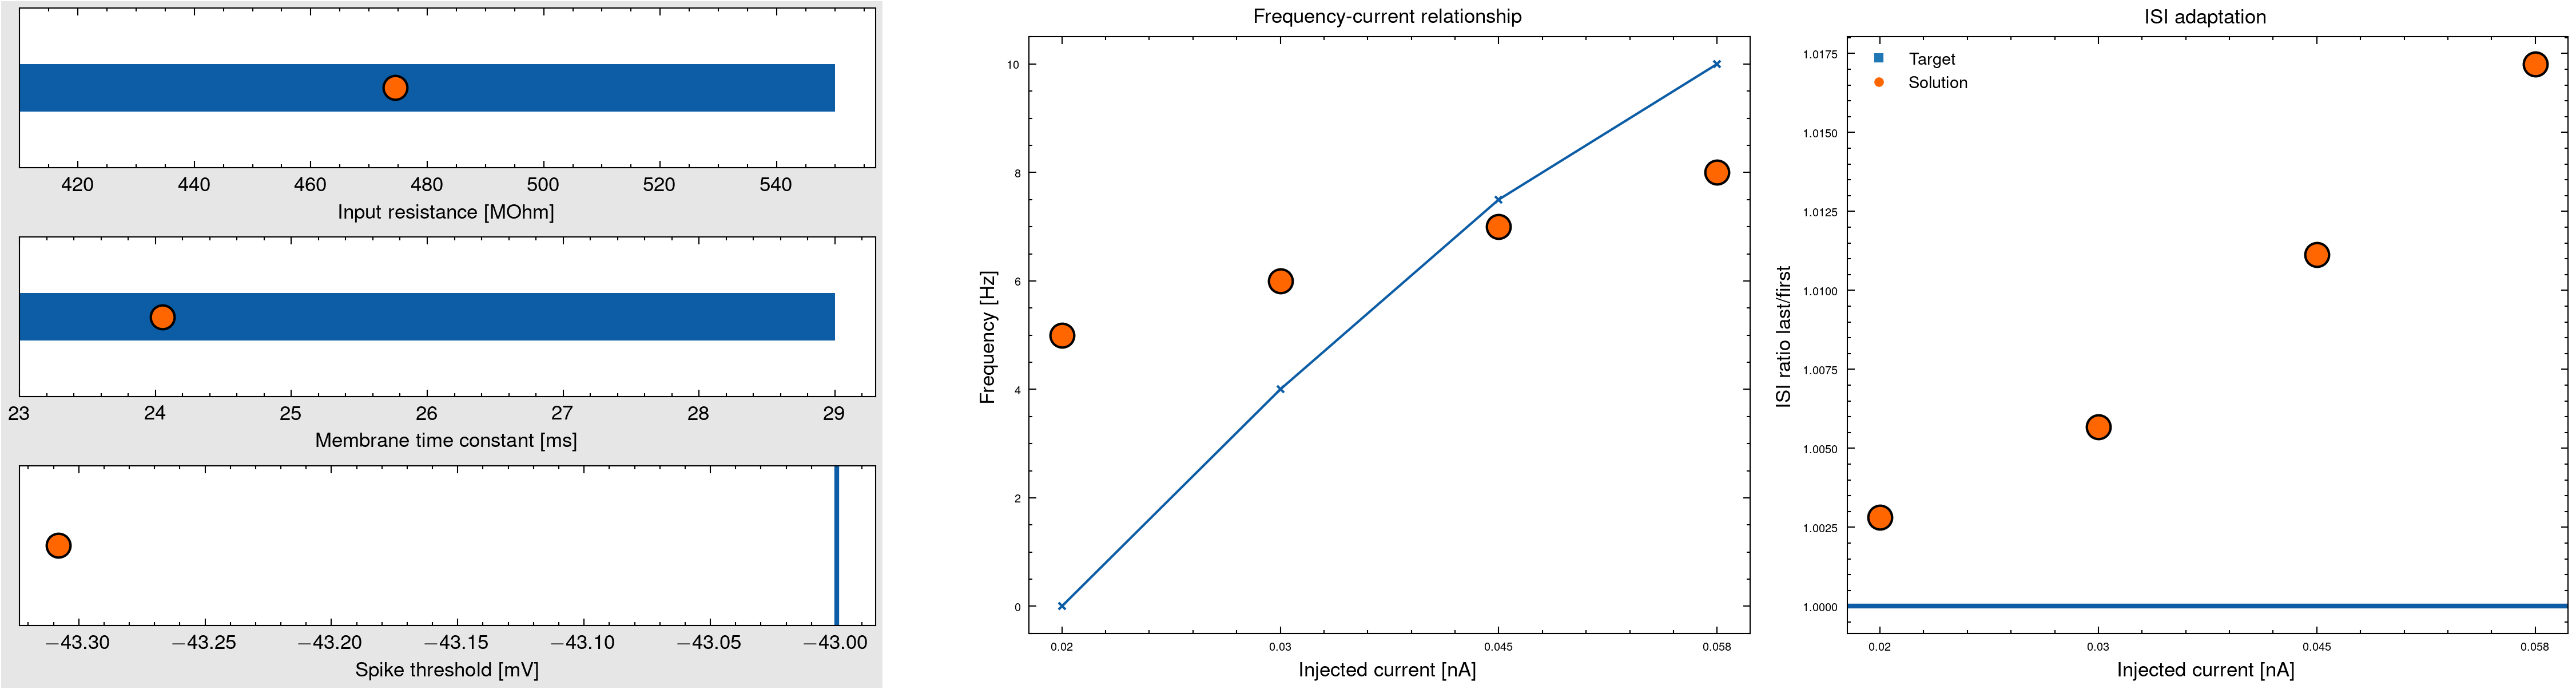

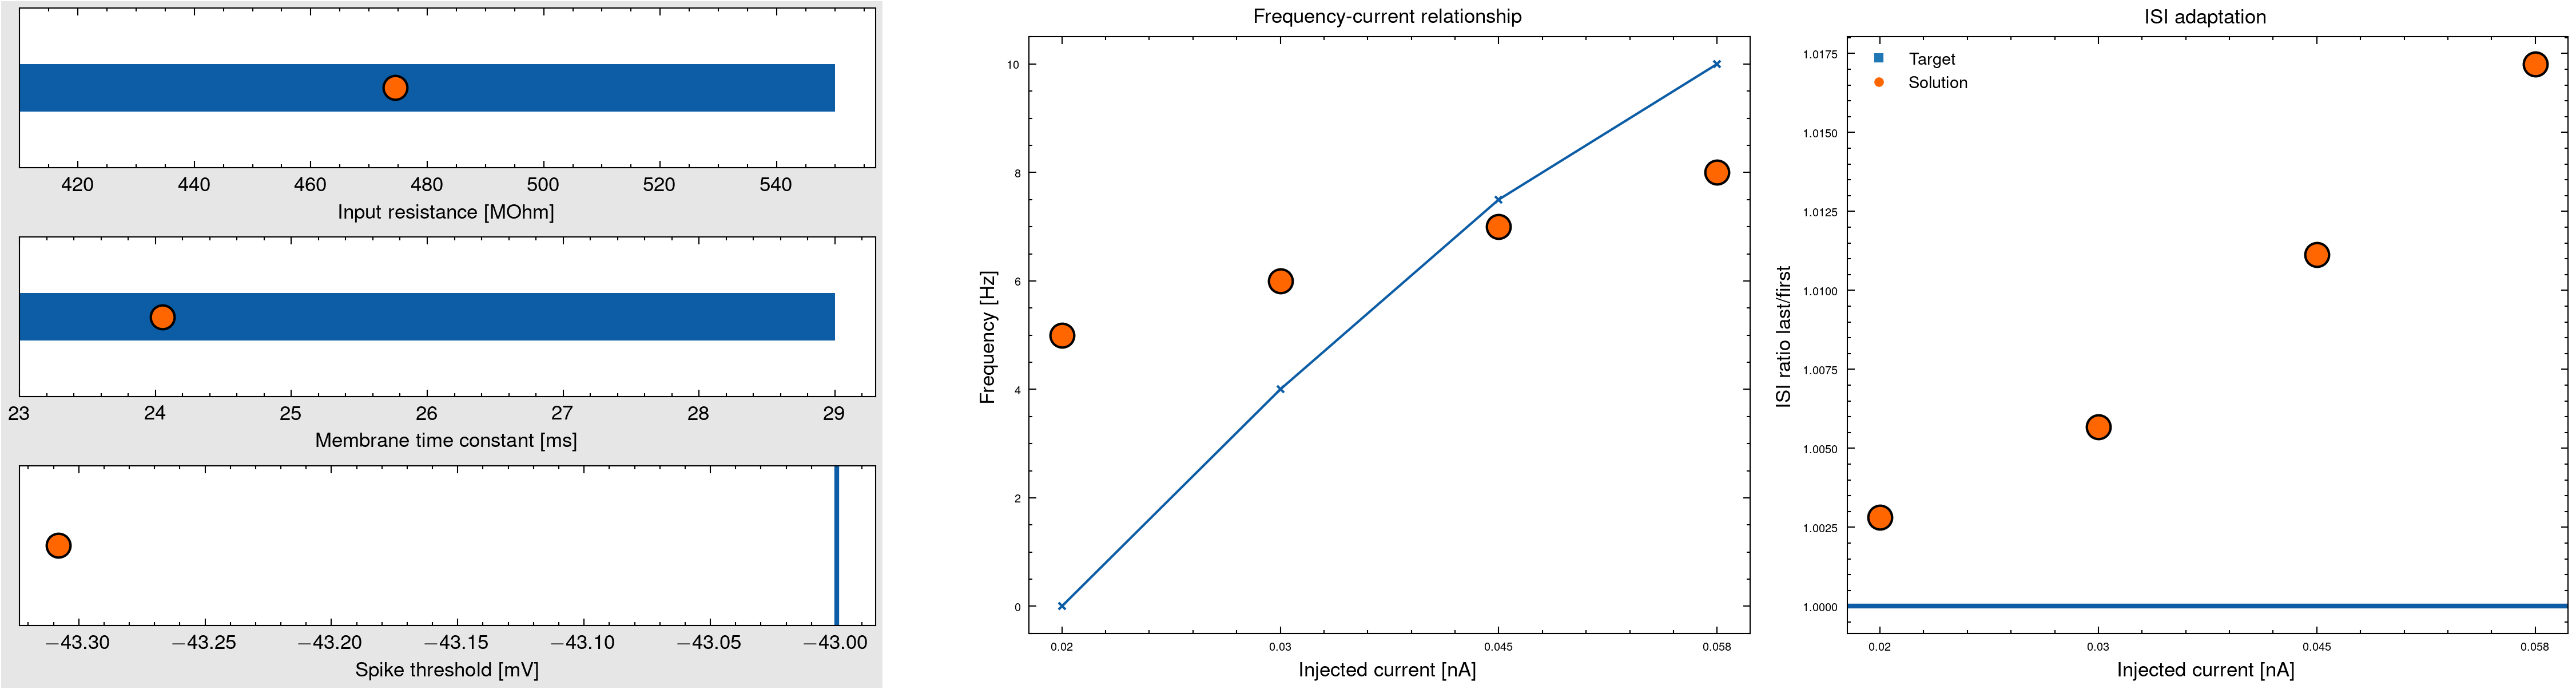

In [15]:
# inspect single datapoint
from benchmarks.modeling.objective import metadata_from_protocol

idx = 67
print(best["y"].iloc[idx])

metadata = metadata_from_protocol(experiment)

experiment.plot_features(best["f"].iloc[idx], metadata=metadata)

In [16]:
param_dict = best["x"].iloc[idx].to_dict()
feature_dict = best["f"].iloc[idx].to_dict()
param_dict.update(
    {k: feature_dict[k] for k in ["ic_constant_hold", "ic_constant_rest"]}
)

In [17]:
param_dict

{'Ltotal': 10.017552375793457,
 'cm_ratio': 42.3085823059082,
 'dend_aqs_KAHP': 0.010938877239823341,
 'dend_beta_Caconc': 0.022184357047080994,
 'dend_bq_KAHP': 1.0,
 'dend_d_Caconc': 5.218293190002441,
 'dend_g_pas': 4.6812245273031294e-05,
 'dend_gmax_Ca': 0.0006211851141415536,
 'dend_gmax_KAHP': 0.8702367544174194,
 'dend_gmax_KCa': 0.9199267625808716,
 'gc': 33.215126037597656,
 'pp': 0.10394203662872314,
 'soma_g_pas': 0.005917216185480356,
 'soma_gmax_K': 0.0010000000474974513,
 'soma_gmax_Na': 0.8828427791595459,
 'ic_constant_hold': -0.018408512696623802,
 'ic_constant_rest': -0.018408512696623802}

INFO:interface.sopt_modeling:{'Ltotal': 10.017552375793457,
 'cm_ratio': 42.3085823059082,
 'dend_aqs_KAHP': 0.010938877239823341,
 'dend_beta_Caconc': 0.022184357047080994,
 'dend_bq_KAHP': 1.0,
 'dend_d_Caconc': 5.218293190002441,
 'dend_g_pas': 4.6812245273031294e-05,
 'dend_gmax_Ca': 0.0006211851141415536,
 'dend_gmax_KAHP': 0.8702367544174194,
 'dend_gmax_KCa': 0.9199267625808716,
 'e_pas': -62,
 'gc': 33.215126037597656,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'ic_constant_hold': -0.018408512696623802,
 'ic_constant_rest': -0.018408512696623802,
 'pp': 0.10394203662872314,
 'soma_g_pas': 0.005917216185480356,
 'soma_gmax_K': 0.0010000000474974513,
 'soma_gmax_Na': 0.8828427791595459}


	1 
PR_nrn[0].soma { nseg=1  L=1.04124  Ra=72158.9
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=126.926}
	insert pas { g_pas=0.00591722 e_pas=-62}
	insert constant { ic_constant=-0.0184085}
	insert Na_PR { gmax_Na_PR=0.882843}
	insert K_PR { gmax_K_PR=0.001}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PR_nrn[0].dend { nseg=1  L=8.97631  Ra=970.957
	PR_nrn[0].soma connect PR_nrn[0].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=4.68122e-05 e_pas=-62}
	insert Ca_PR { gmax_Ca_PR=0.000621185}
	insert KAHP_PR { gmax_KAHP_PR=0.870237 bq_KAHP_PR=1 aqs_KAHP_PR=0.0109389 aqmax_KAHP_PR=0.01}
	insert KCa_PR { gmax_KCa_PR=0.919927}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca

INFO:interface.sopt_modeling:initial_v_error: -0.00035546509044337427
INFO:interface.sopt_modeling:ic_constant0: 0.009205965278226005
INFO:interface.sopt_modeling:ic_constant: -0.018408512696623802
INFO:interface.sopt_modeling:mean initial vm constraint: 0
INFO:interface.sopt_modeling:soma ek = -89.7063966755447 ena = 60.43883162163455
INFO:interface.sopt_modeling:dend ek = -89.7063966755447 eca = 162.58785237096964
INFO:interface.sopt_modeling:soma nao = 145.0 ko = 5.0
INFO:interface.sopt_modeling:dend ki = 145.0 ko = 5.0
INFO:interface.sopt_modeling:dend cao = 2.0 cai = 1e-05
INFO:interface.sopt_modeling:spikes: (0, 7, -43.7055076005686, array([(29.9524334 , 503.39, 73.657941  , 500.01, 507.48), (25.24579734, 572.07, 68.95130494, 507.49, 575.31), (25.26396702, 650.82, 68.96947462, 575.32, 654.06), (25.25731462, 729.54, 68.96282222, 654.07, 732.81), (25.2672221 , 808.29, 68.9727297 , 732.82, 811.56), (25.2623944 , 887.04, 68.967902  , 811.57, 890.28), (25.25755587, 965.77, 68.96306347

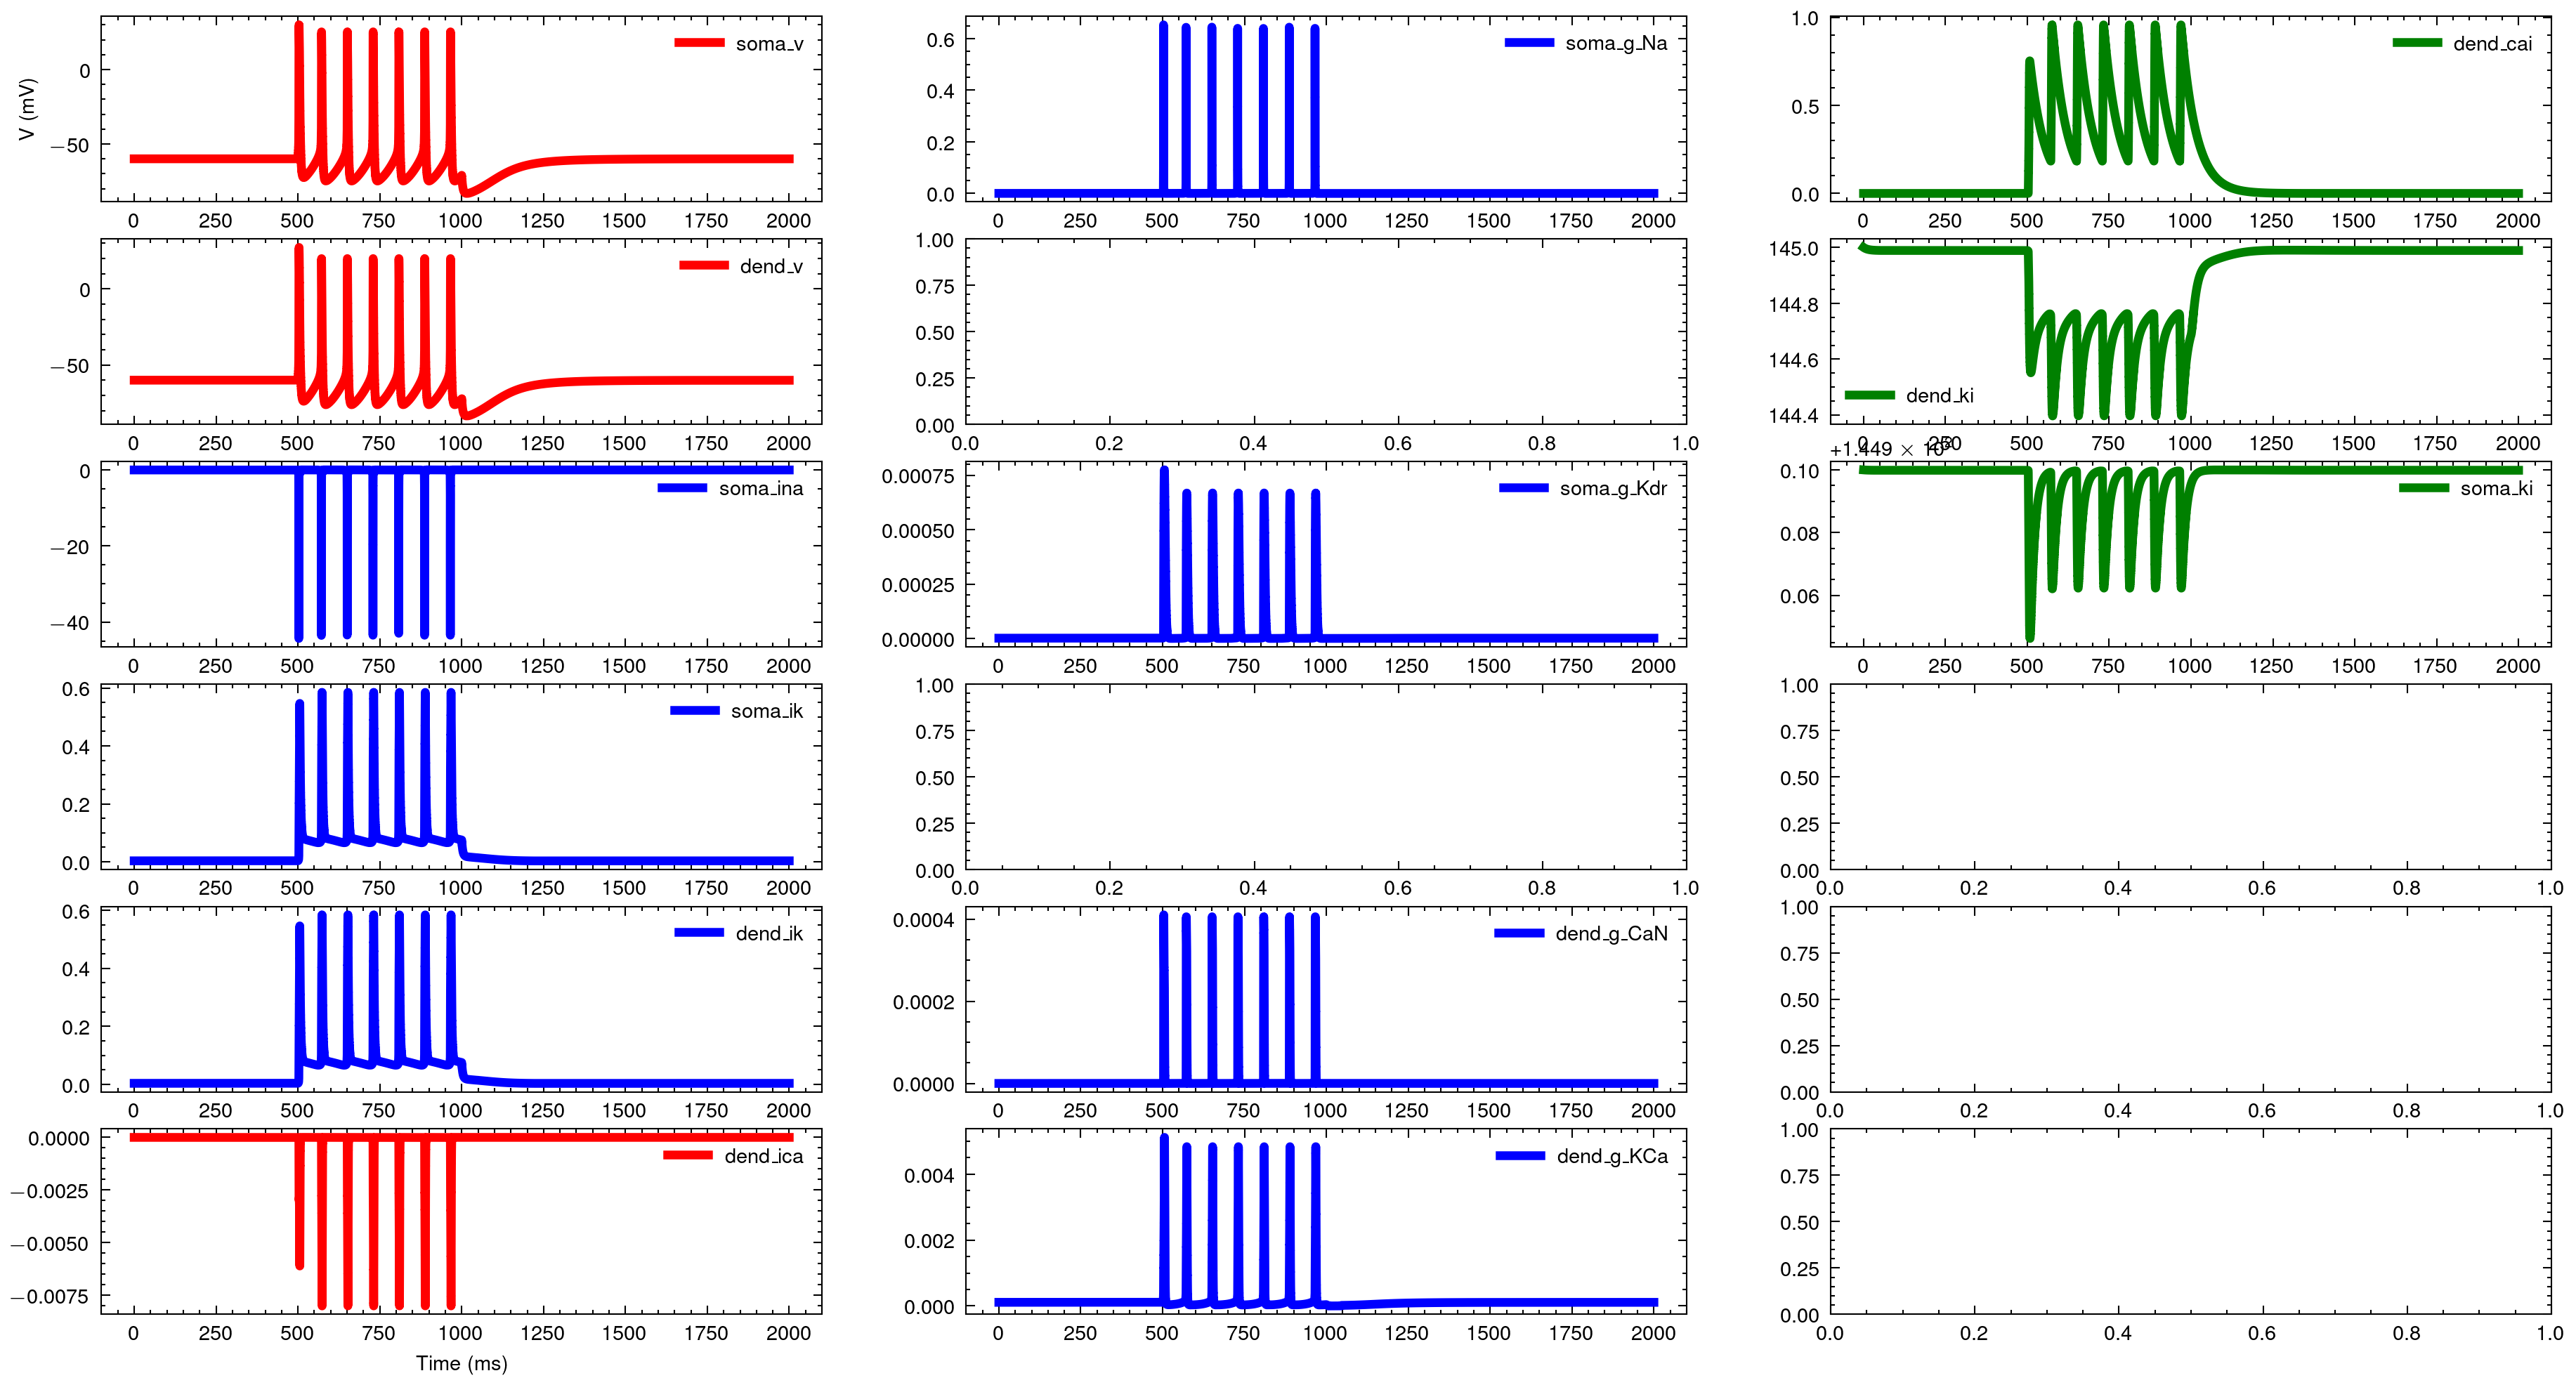

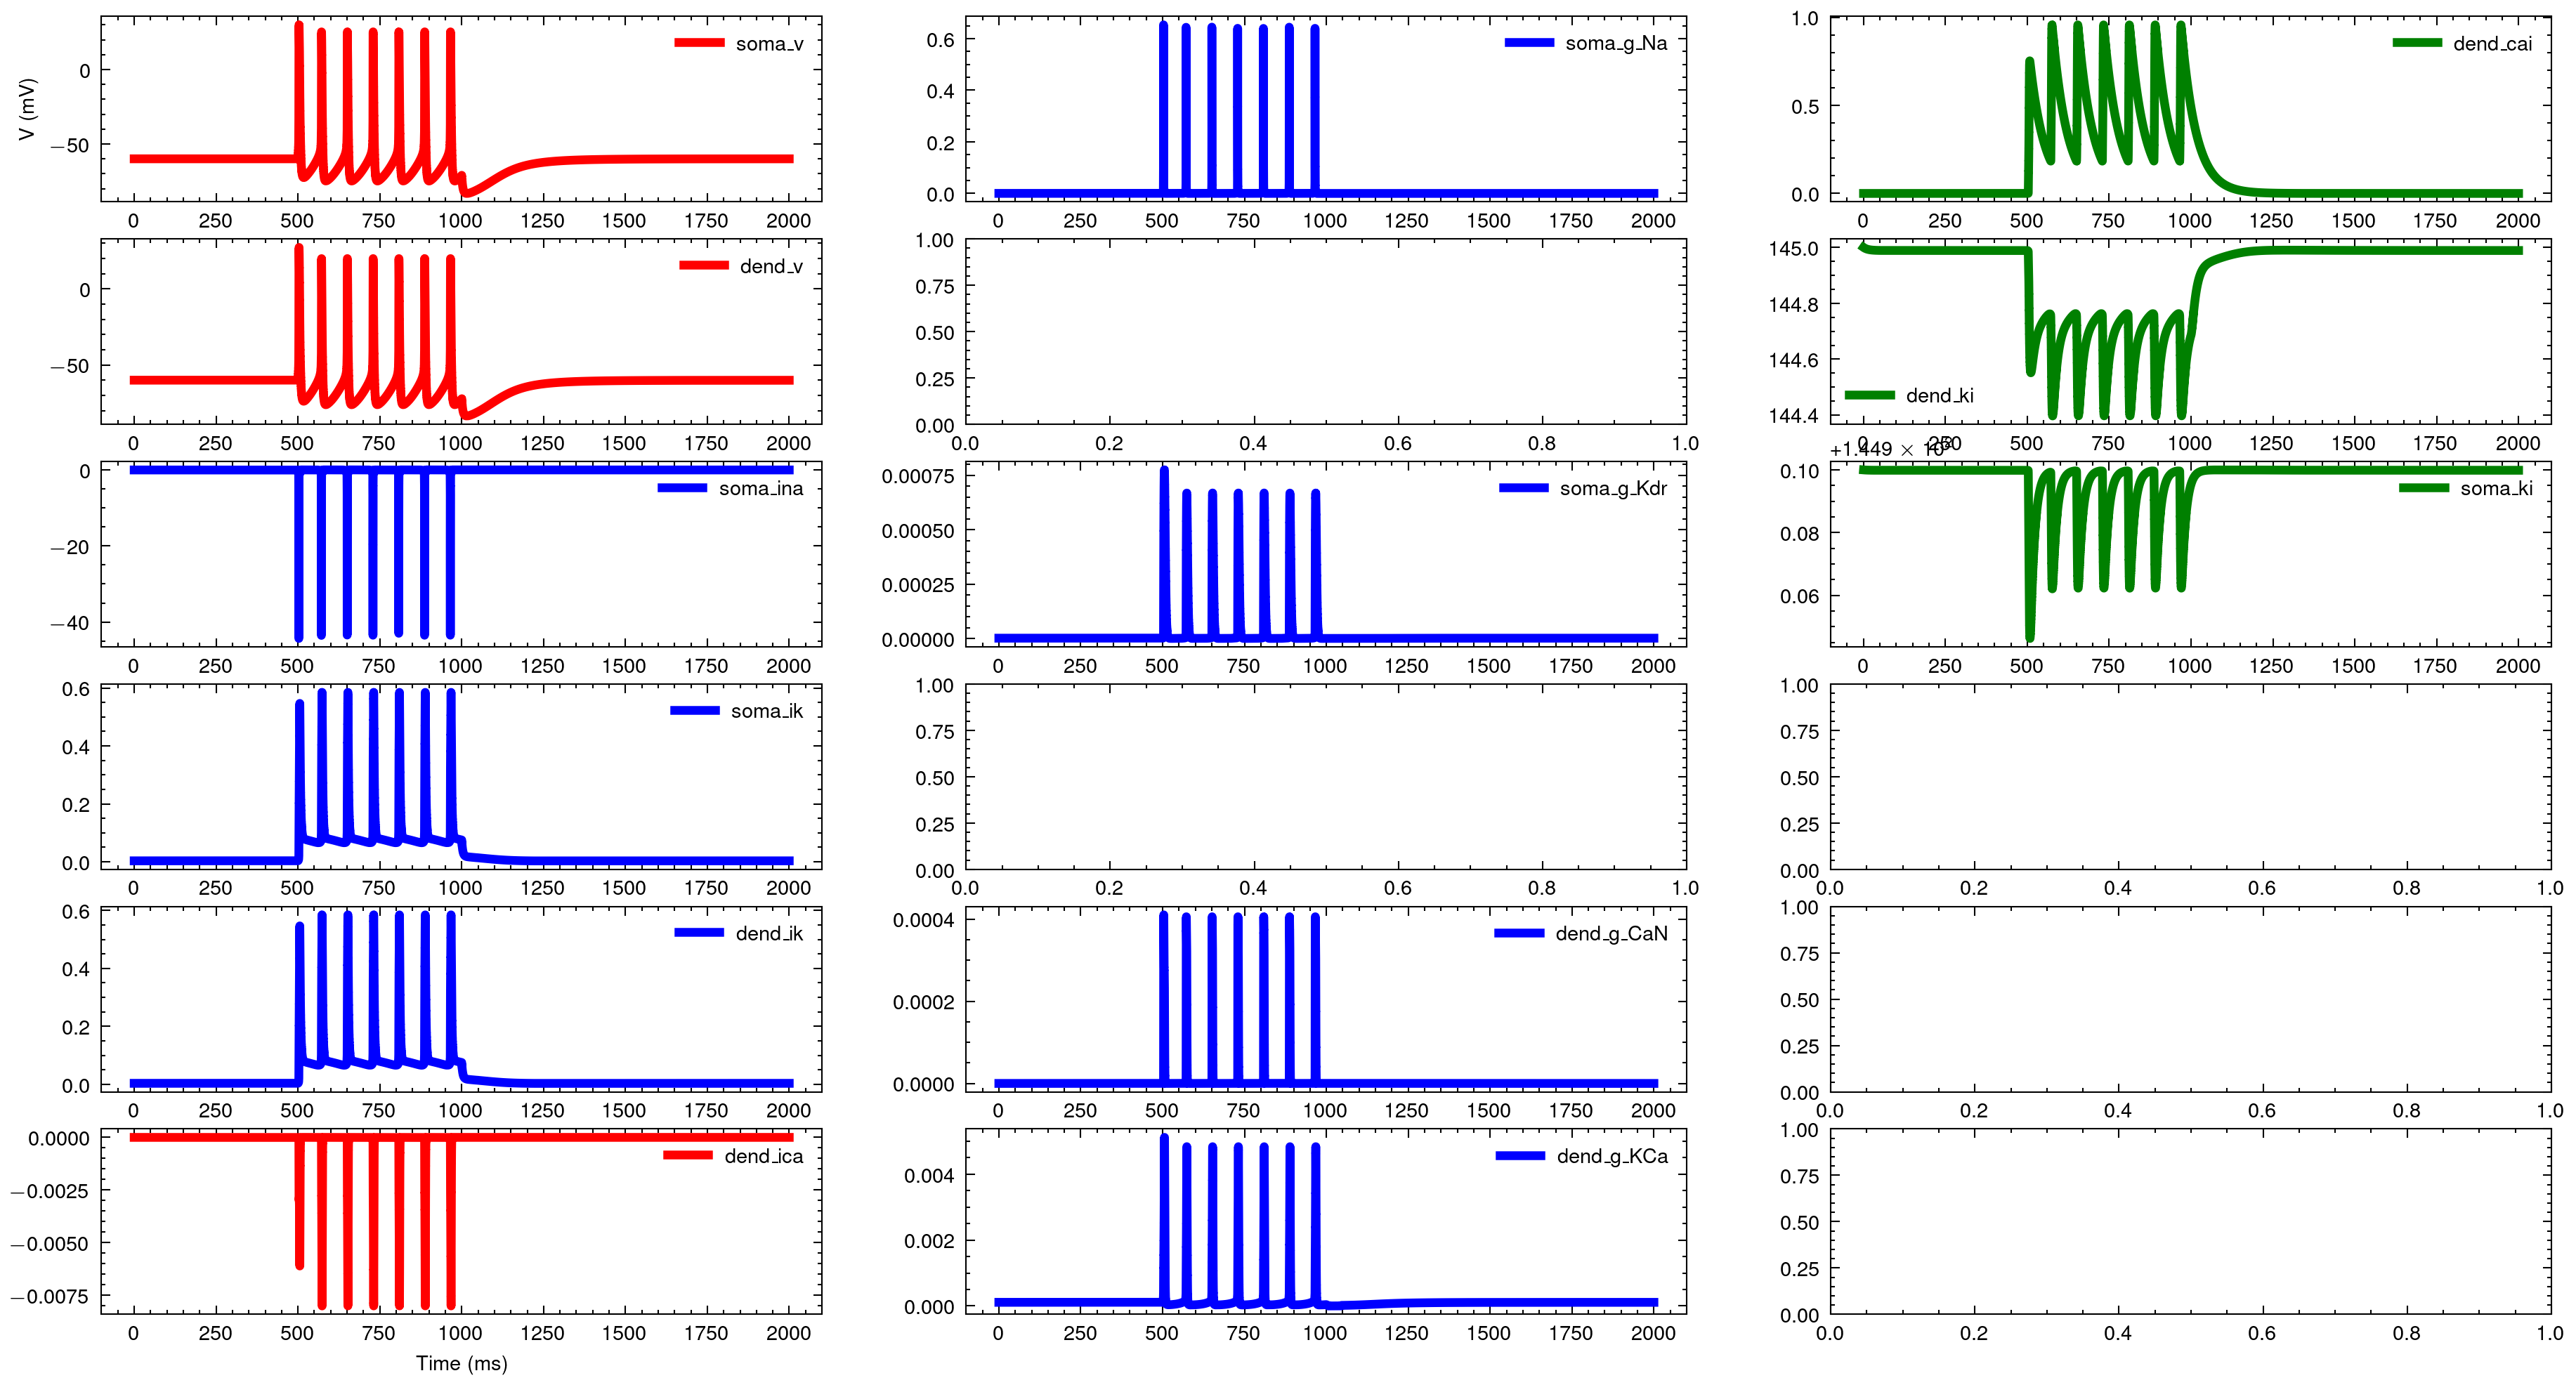

In [18]:
experiment.plot_iclamp(param_dict=param_dict, stim_amp=0.2)

In [ ]:
ivy = _ca1_sopt_baseline.components.first(
    lambda x: x.cell_type == 'IVY' and x.trial == 0 and x.mO == '-'  # no surrogate, set to 'megp' or 'gpr'
)

ivy.plot_features(best["IVY"]["f"].iloc[0], metadata=metadata_from_protocol(ivy));

None


AttributeError: 'NoneType' object has no attribute 'plot_features'

In [44]:
solution_index = 0
param_dict = best["IVY"]["x"].iloc[solution_index].to_dict()
feature_dict = best["IVY"]["f"].iloc[solution_index].to_dict()
param_dict.update(
    {k: feature_dict[k] for k in ["ic_constant_hold", "ic_constant_rest"]}
)

NEURON: Couldn't find: rn.hoc
 near line 0
 ^
INFO:interface.sopt_modeling:{'Ltotal': 10.24291706085205,
 'cm_ratio': 45.7627067565918,
 'dend_beta_Caconc': 0.010030322708189487,
 'dend_d_Caconc': 20.0,
 'dend_g_pas': 0.0003651385777629912,
 'dend_gmax_Ca': 0.6605327129364014,
 'dend_gmax_KCa': 0.9954869747161865,
 'e_pas': -62,
 'gc': 37.8539924621582,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'ic_constant_hold': -0.026461713016033173,
 'ic_constant_rest': -0.01663380116224289,
 'pp': 0.5245572924613953,
 'soma_g_pas': 0.0018823655555024743,
 'soma_gmax_K': 0.8779263496398926,
 'soma_gmax_Na': 0.4690789580345154}
INFO:interface.sopt_modeling:initial_v_error: 3.667992765343797e-05
INFO:interface.sopt_modeling:ic_constant0: -0.014758000032927078
INFO:interface.sopt_modeling:ic_constant: -0.01663380116224289
INFO:interface.sopt_modeling:mean initial vm constraint: 1
INFO:interface.sopt_modeling:soma ek = -89.7063966755447 ena = 60.43883162163455
INFO:interface.sopt_modeling:dend ek = -89

PRN_nrn[21].soma { nseg=1  L=5.373  Ra=12000.2
	/*location 0 attached to cell 1*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=137.288}
	insert pas { g_pas=0.00188237 e_pas=-62}
	insert constant { ic_constant=-0.0166338}
	insert Na_PR { gmax_Na_PR=0.469079}
	insert K_PR { gmax_K_PR=0.877926}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PRN_nrn[21].dend { nseg=1  L=4.86992  Ra=14607.6
	PRN_nrn[21].soma connect PRN_nrn[21].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=0.000365139 e_pas=-62}
	insert Ca_PR { gmax_Ca_PR=0.660533}
	insert KCa_PR { gmax_KCa_PR=0.995487}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca_conc_PR=20 beta_Ca_conc_PR=0.0100303}
	insert ca_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 

INFO:interface.sopt_modeling:spikes: (0, 14, -42.93791754453396, array([(1.5176297 , 514.09, 44.45554725, 500.01, 514.96),
       (0.2842088 , 554.07, 43.22212635, 514.97, 554.91),
       (0.52123078, 589.67, 43.45914833, 554.92, 590.51),
       (0.57013739, 624.24, 43.50805493, 590.52, 625.11),
       (0.60936636, 658.72, 43.5472839 , 625.12, 659.56),
       (0.59287669, 693.17, 43.53079423, 659.57, 694.03),
       (0.58806268, 727.64, 43.52598023, 694.04, 728.48),
       (0.60761929, 762.09, 43.54553684, 728.49, 762.93),
       (0.61060583, 796.54, 43.54852337, 762.94, 797.38),
       (0.60022464, 830.99, 43.53814219, 797.39, 831.86),
       (0.57679471, 865.47, 43.51471226, 831.87, 866.31),
       (0.60232274, 899.92, 43.54024029, 866.32, 900.76),
       (0.61130557, 934.37, 43.54922311, 900.77, 935.21),
       (0.60540899, 968.82, 43.54332653, 935.22, 969.68)],
      dtype=[('Vpeak', '<f8'), ('Tpeak', '<f8'), ('amplitude', '<f8'), ('T0', '<f8'), ('T1', '<f8')]))
INFO:interface.sopt

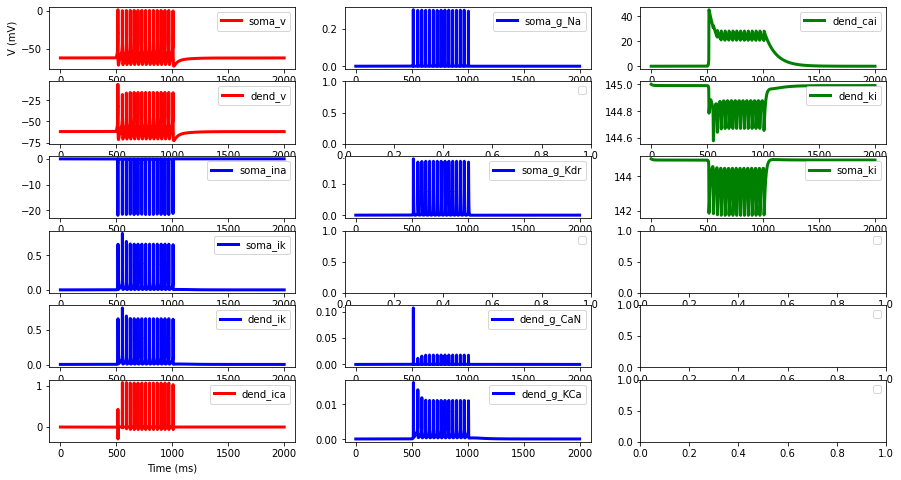

In [45]:
ivy.plot_iclamp(param_dict=param_dict, stim_amp=0.2);

NEURON: Couldn't find: rn.hoc
 near line 0
 ^
INFO:interface.sopt_modeling:{'Ltotal': 10.24291706085205,
 'cm_ratio': 45.7627067565918,
 'dend_beta_Caconc': 0.010030322708189487,
 'dend_d_Caconc': 20.0,
 'dend_g_pas': 0.0003651385777629912,
 'dend_gmax_Ca': 0.6605327129364014,
 'dend_gmax_KCa': 0.9954869747161865,
 'e_pas': -62,
 'gc': 37.8539924621582,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'ic_constant_hold': -0.026461713016033173,
 'ic_constant_rest': -0.01663380116224289,
 'pp': 0.5245572924613953,
 'soma_g_pas': 0.0018823655555024743,
 'soma_gmax_K': 0.8779263496398926,
 'soma_gmax_Na': 0.4690789580345154}


PRN_nrn[23].soma { nseg=1  L=5.373  Ra=12000.2
	/*location 0 attached to cell 1*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=137.288}
	insert pas { g_pas=0.00188237 e_pas=-62}
	insert constant { ic_constant=-0.0166338}
	insert Na_PR { gmax_Na_PR=0.469079}
	insert K_PR { gmax_K_PR=0.877926}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PRN_nrn[23].dend { nseg=1  L=4.86992  Ra=14607.6
	PRN_nrn[23].soma connect PRN_nrn[23].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=0.000365139 e_pas=-62}
	insert Ca_PR { gmax_Ca_PR=0.660533}
	insert KCa_PR { gmax_KCa_PR=0.995487}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca_conc_PR=20 beta_Ca_conc_PR=0.0100303}
	insert ca_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 

INFO:interface.sopt_modeling:initial_v_error: 3.667992765343797e-05
INFO:interface.sopt_modeling:ic_constant0: -0.014758000032927078
INFO:interface.sopt_modeling:ic_constant: -0.01663380116224289
INFO:interface.sopt_modeling:mean initial vm constraint: 1
INFO:interface.sopt_modeling:soma ek = -89.7063966755447 ena = 60.43883162163455
INFO:interface.sopt_modeling:dend ek = -89.7063966755447 eca = 162.58785237096964
INFO:interface.sopt_modeling:soma nao = 145.0 ko = 5.0
INFO:interface.sopt_modeling:dend ki = 145.0 ko = 5.0
INFO:interface.sopt_modeling:dend cao = 2.0 cai = 1e-05
INFO:interface.sopt_modeling:spikes: (0, 42, -43.417467946913185, array([( 2.87915899,  504.59, 46.29662694, 500.01,  505.46),
       ( 0.94728399,  517.87, 44.36475194, 505.47,  518.78),
       ( 0.51806205,  530.47, 43.93552999, 518.79,  531.41),
       ( 0.37045981,  542.84, 43.78792776, 531.42,  543.78),
       ( 0.29943295,  555.07, 43.71690089, 543.79,  556.03),
       ( 0.27042592,  567.19, 43.68789386, 556

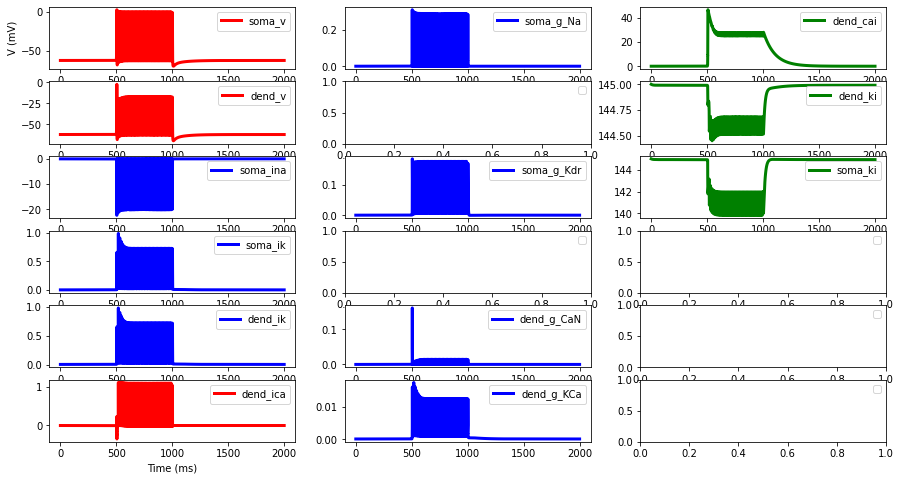

In [46]:
ivy.plot_iclamp(param_dict=param_dict, stim_amp=0.8);

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

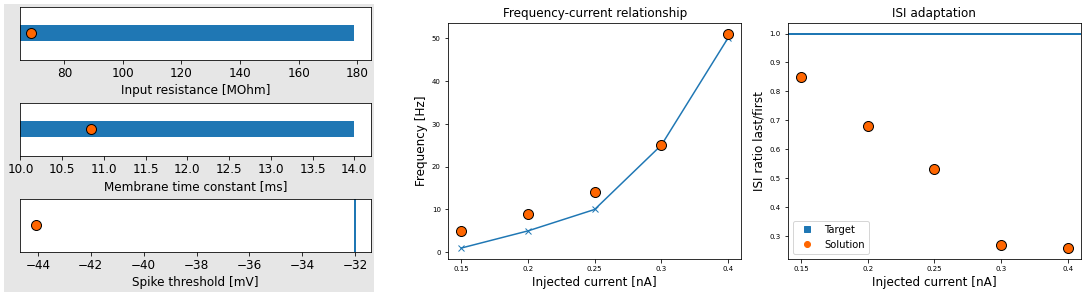

In [48]:
aac = interface.components[4]

aac.plot_features(best["AAC"]["f"].iloc[0]);

In [ ]:
solution_index = 0
param_dict = best["AAC"]["x"].iloc[solution_index].to_dict()
feature_dict = best["AAC"]["f"].iloc[solution_index].to_dict()
param_dict.update(
    {k: feature_dict[k] for k in ["ic_constant_hold", "ic_constant_rest"]}
)

NEURON: Couldn't find: rn.hoc
 near line 0
 ^
INFO:interface.sopt_modeling:{'Ltotal': 10.24291706085205,
 'cm_ratio': 45.7627067565918,
 'dend_beta_Caconc': 0.010030322708189487,
 'dend_d_Caconc': 20.0,
 'dend_g_pas': 0.0003651385777629912,
 'dend_gmax_Ca': 0.6605327129364014,
 'dend_gmax_KCa': 0.9954869747161865,
 'e_pas': -62,
 'gc': 37.8539924621582,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'ic_constant_hold': -0.026461713016033173,
 'ic_constant_rest': -0.01663380116224289,
 'pp': 0.5245572924613953,
 'soma_g_pas': 0.0018823655555024743,
 'soma_gmax_K': 0.8779263496398926,
 'soma_gmax_Na': 0.4690789580345154}


PRN_nrn[25].soma { nseg=1  L=5.373  Ra=12000.2
	/*location 0 attached to cell 1*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=137.288}
	insert pas { g_pas=0.00188237 e_pas=-62}
	insert constant { ic_constant=-0.0166338}
	insert Na_PR { gmax_Na_PR=0.469079}
	insert K_PR { gmax_K_PR=0.877926}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PRN_nrn[25].dend { nseg=1  L=4.86992  Ra=14607.6
	PRN_nrn[25].soma connect PRN_nrn[25].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=0.000365139 e_pas=-62}
	insert Ca_PR { gmax_Ca_PR=0.660533}
	insert KCa_PR { gmax_KCa_PR=0.995487}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca_conc_PR=20 beta_Ca_conc_PR=0.0100303}
	insert ca_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 

INFO:interface.sopt_modeling:initial_v_error: 1.723651118164483
INFO:interface.sopt_modeling:ic_constant0: -0.006431875639216149
INFO:interface.sopt_modeling:ic_constant: -0.01663380116224289
INFO:interface.sopt_modeling:mean initial vm constraint: 0
INFO:interface.sopt_modeling:soma ek = -89.7063966755447 ena = 60.43883162163455
INFO:interface.sopt_modeling:dend ek = -89.7063966755447 eca = 162.58785237096964
INFO:interface.sopt_modeling:soma nao = 145.0 ko = 5.0
INFO:interface.sopt_modeling:dend ki = 145.0 ko = 5.0
INFO:interface.sopt_modeling:dend cao = 2.0 cai = 1e-05
INFO:interface.sopt_modeling:spikes: (0, 14, -42.82703114722163, array([(1.40110373, 514.64, 44.22813488, 500.01, 515.48),
       (0.33525034, 553.64, 43.16228148, 515.49, 554.48),
       (0.51800774, 588.99, 43.34503889, 554.49, 589.83),
       (0.58447455, 623.59, 43.41150569, 589.84, 624.43),
       (0.58462438, 658.12, 43.41165553, 624.44, 658.96),
       (0.59151044, 692.62, 43.41854159, 658.97, 693.46),
       (

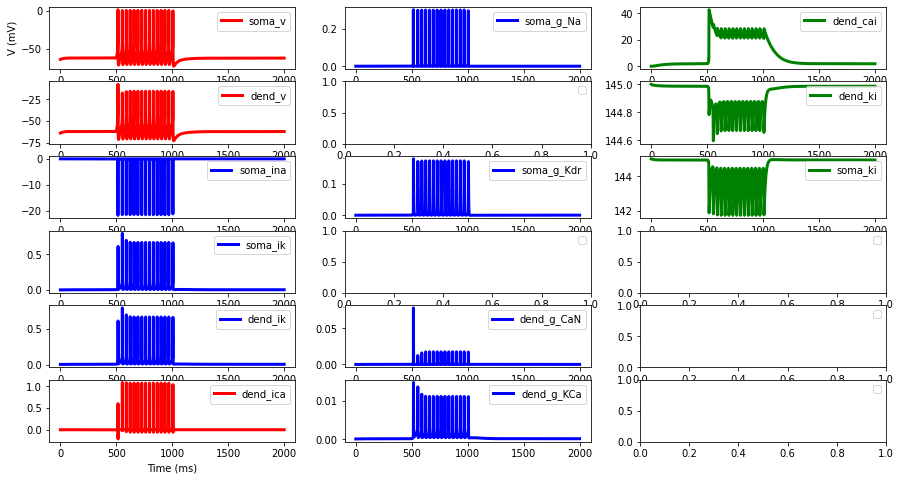

In [49]:
aac.plot_iclamp(param_dict=param_dict, stim_amp=0.2);

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

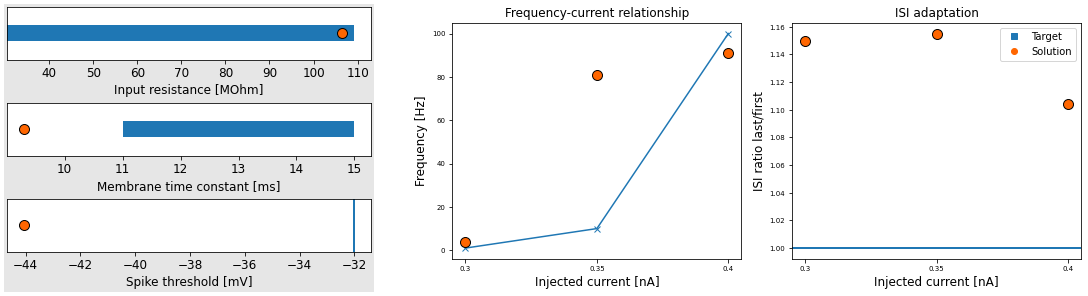

In [50]:
bs = interface.components[5]

bs.plot_features(best["BS"]["f"].iloc[0]);

In [52]:
solution_index = 0
param_dict = best["BS"]["x"].iloc[solution_index].to_dict()
feature_dict = best["BS"]["f"].iloc[solution_index].to_dict()
param_dict.update(
    {k: feature_dict[k] for k in ["ic_constant_hold", "ic_constant_rest"]}
)

NEURON: Couldn't find: rn.hoc
 near line 0
 ^
INFO:interface.sopt_modeling:{'Ltotal': 52.619998931884766,
 'cm_ratio': 3.2247045040130615,
 'dend_beta_Caconc': 0.009999999776482582,
 'dend_d_Caconc': 18.89783477783203,
 'dend_g_pas': 0.0,
 'dend_gmax_Ca': 0.3053312599658966,
 'dend_gmax_KCa': 0.5734518766403198,
 'e_pas': -62,
 'gc': 5.211365699768066,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'ic_constant_hold': -0.04363948479294777,
 'ic_constant_rest': -0.018395932391285896,
 'pp': 0.13107240200042725,
 'soma_g_pas': 0.0009613657603040338,
 'soma_gmax_K': 0.9980916976928711,
 'soma_gmax_Na': 0.20377060770988464}


PRN_nrn[0].soma { nseg=1  L=6.89703  Ra=13218.3
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=9.67411}
	insert pas { g_pas=0.000961366 e_pas=-62}
	insert constant { ic_constant=-0.0183959}
	insert Na_PR { gmax_Na_PR=0.203771}
	insert K_PR { gmax_K_PR=0.998092}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PRN_nrn[0].dend { nseg=1  L=45.723  Ra=300.767
	PRN_nrn[0].soma connect PRN_nrn[0].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=0 e_pas=-62}
	insert Ca_PR { gmax_Ca_PR=0.305331}
	insert KCa_PR { gmax_KCa_PR=0.573452}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca_conc_PR=18.8978 beta_Ca_conc_PR=0.01}
	insert ca_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_P

INFO:interface.sopt_modeling:initial_v_error: 1.1103757437069817e-05
INFO:interface.sopt_modeling:ic_constant0: -0.011249685299568102
INFO:interface.sopt_modeling:ic_constant: -0.018395932391285896
INFO:interface.sopt_modeling:mean initial vm constraint: 1
INFO:interface.sopt_modeling:soma ek = -89.7063966755447 ena = 60.43883162163455
INFO:interface.sopt_modeling:dend ek = -89.7063966755447 eca = 162.58785237096964
INFO:interface.sopt_modeling:soma nao = 145.0 ko = 5.0
INFO:interface.sopt_modeling:dend ki = 145.0 ko = 5.0
INFO:interface.sopt_modeling:dend cao = 2.0 cai = 1e-05
INFO:interface.sopt_modeling:spikes: (0, 1, -43.762972862044236, array([(12.54458815, 505.44, 56.30756101, 500.01, 505.73)],
      dtype=[('Vpeak', '<f8'), ('Tpeak', '<f8'), ('amplitude', '<f8'), ('T0', '<f8'), ('T1', '<f8')]))
INFO:interface.sopt_modeling:dend ki min/max: 144.9699287393854 / 145.0


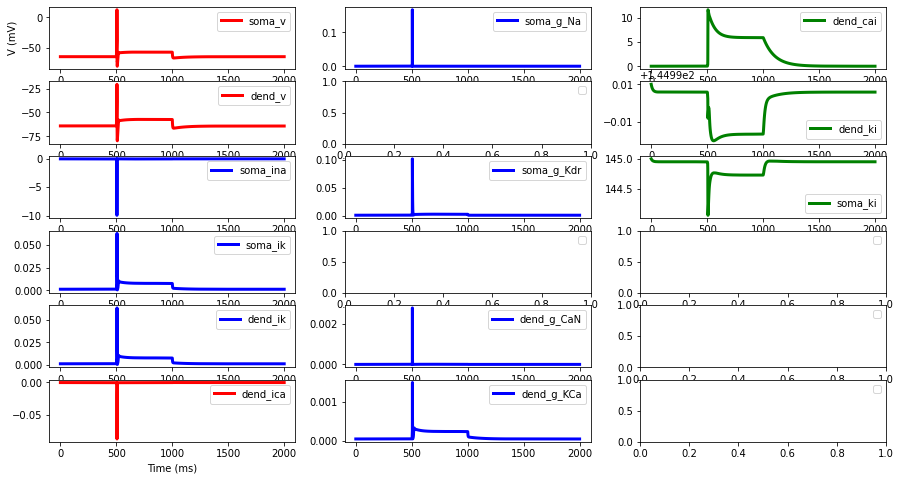

In [53]:
bs.plot_iclamp(param_dict=param_dict, stim_amp=0.2);

NEURON: Couldn't find: rn.hoc
 near line 0
 ^
INFO:interface.sopt_modeling:{'Ltotal': 52.619998931884766,
 'cm_ratio': 3.2247045040130615,
 'dend_beta_Caconc': 0.009999999776482582,
 'dend_d_Caconc': 18.89783477783203,
 'dend_g_pas': 0.0,
 'dend_gmax_Ca': 0.3053312599658966,
 'dend_gmax_KCa': 0.5734518766403198,
 'e_pas': -62,
 'gc': 5.211365699768066,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'ic_constant_hold': -0.04363948479294777,
 'ic_constant_rest': -0.018395932391285896,
 'pp': 0.13107240200042725,
 'soma_g_pas': 0.0009613657603040338,
 'soma_gmax_K': 0.9980916976928711,
 'soma_gmax_Na': 0.20377060770988464}
INFO:interface.sopt_modeling:initial_v_error: 1.1103757437069817e-05
INFO:interface.sopt_modeling:ic_constant0: -0.011249685299568102
INFO:interface.sopt_modeling:ic_constant: -0.018395932391285896
INFO:interface.sopt_modeling:mean initial vm constraint: 1
INFO:interface.sopt_modeling:soma ek = -89.7063966755447 ena = 60.43883162163455
INFO:interface.sopt_modeling:dend ek = 

PRN_nrn[0].soma { nseg=1  L=6.89703  Ra=13218.3
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=9.67411}
	insert pas { g_pas=0.000961366 e_pas=-62}
	insert constant { ic_constant=-0.0183959}
	insert Na_PR { gmax_Na_PR=0.203771}
	insert K_PR { gmax_K_PR=0.998092}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PRN_nrn[0].dend { nseg=1  L=45.723  Ra=300.767
	PRN_nrn[0].soma connect PRN_nrn[0].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=0 e_pas=-62}
	insert Ca_PR { gmax_Ca_PR=0.305331}
	insert KCa_PR { gmax_KCa_PR=0.573452}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca_conc_PR=18.8978 beta_Ca_conc_PR=0.01}
	insert ca_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_P

INFO:interface.sopt_modeling:spikes: (0, 65, -46.002626751575626, array([(14.11470567, 501.22, 60.11733242, 500.01, 501.53),
       (12.13612115, 508.67, 58.13874791, 501.54, 508.98),
       (11.56644691, 516.12, 57.56907366, 508.99, 516.43),
       (10.93867535, 523.64, 56.9413021 , 516.44, 523.98),
       (11.23167523, 531.24, 57.23430198, 523.99, 531.56),
       (11.02499365, 538.87, 57.0276204 , 531.57, 539.18),
       (11.08004412, 546.52, 57.08267087, 539.19, 546.83),
       (11.02381631, 554.19, 57.02644306, 546.84, 554.51),
       (11.00142402, 561.87, 57.00405077, 554.52, 562.21),
       (10.79520586, 569.59, 56.79783261, 562.22, 569.91),
       (11.24058851, 577.29, 57.24321526, 569.92, 577.61),
       (11.25750191, 585.02, 57.26012866, 577.62, 585.33),
       (11.01078633, 592.74, 57.01341308, 585.34, 593.08),
       (11.0730119 , 600.49, 57.07563865, 593.09, 600.81),
       (11.13609832, 608.22, 57.13872507, 600.82, 608.53),
       (11.25555175, 615.97, 57.2581785 , 608.54,

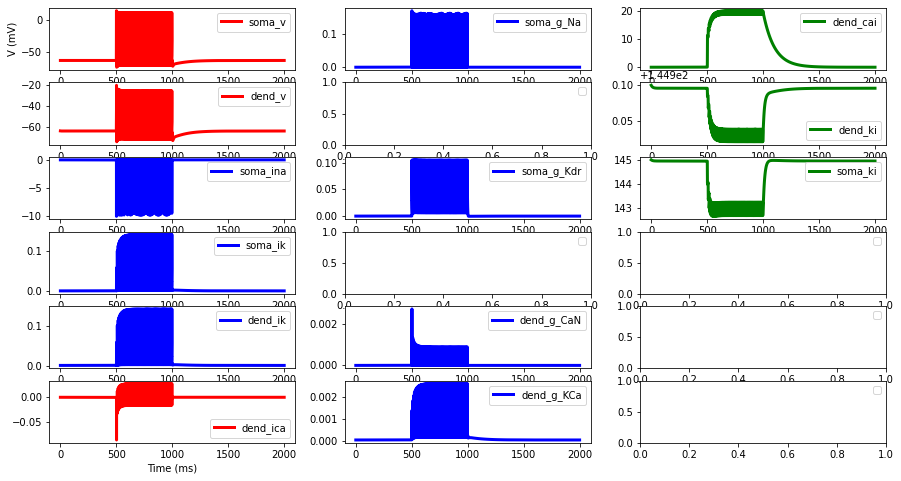

In [54]:
bs.plot_iclamp(param_dict=param_dict, stim_amp=0.8);

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

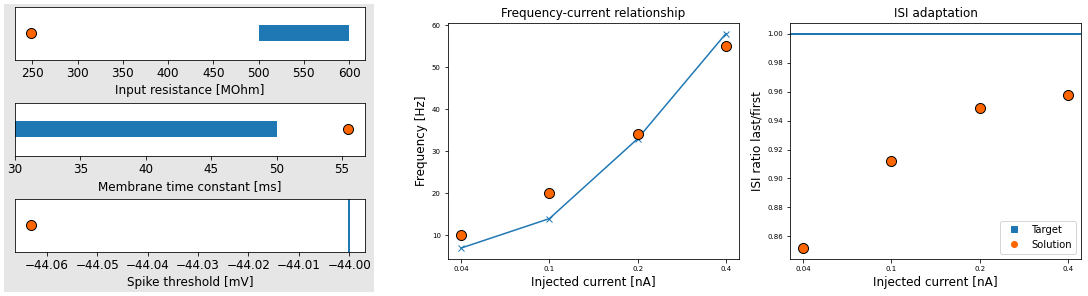

In [56]:
olm = interface.components[6]

olm.plot_features(best["OLM"]["f"].iloc[0]);

In [57]:
solution_index = 0
param_dict = best["OLM"]["x"].iloc[solution_index].to_dict()
feature_dict = best["OLM"]["f"].iloc[solution_index].to_dict()
param_dict.update(
    {k: feature_dict[k] for k in ["ic_constant_hold", "ic_constant_rest"]}
)

NEURON: Couldn't find: rn.hoc
 near line 0
 ^
INFO:interface.sopt_modeling:{'Ltotal': 21.01412010192871,
 'cm_ratio': 13.39218521118164,
 'dend_beta_Caconc': 0.009999999776482582,
 'dend_d_Caconc': 4.910271167755127,
 'dend_g_pas': 0.0,
 'dend_gmax_Ca': 0.3274633586406708,
 'dend_gmax_KCa': 0.7911216616630554,
 'e_pas': -62,
 'gc': 43.92416000366211,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'ic_constant_hold': -0.004158392548561096,
 'ic_constant_rest': -0.0005428391741588712,
 'pp': 0.7587454915046692,
 'soma_g_pas': 0.0006923977052792907,
 'soma_gmax_K': 0.2911522686481476,
 'soma_gmax_Na': 0.33878931403160095}


PRN_nrn[0].soma { nseg=1  L=15.9444  Ra=1698.71
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=40.1766}
	insert pas { g_pas=0.000692398 e_pas=-62}
	insert constant { ic_constant=-0.000542839}
	insert Na_PR { gmax_Na_PR=0.338789}
	insert K_PR { gmax_K_PR=0.291152}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PRN_nrn[0].dend { nseg=1  L=5.06975  Ra=16801.9
	PRN_nrn[0].soma connect PRN_nrn[0].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=0 e_pas=-62}
	insert Ca_PR { gmax_Ca_PR=0.327463}
	insert KCa_PR { gmax_KCa_PR=0.791122}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca_conc_PR=4.91027 beta_Ca_conc_PR=0.01}
	insert ca_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_con

INFO:interface.sopt_modeling:initial_v_error: 1.966341454817666e-05
INFO:interface.sopt_modeling:ic_constant0: -0.0001111549940725166
INFO:interface.sopt_modeling:ic_constant: -0.0005428391741588712
INFO:interface.sopt_modeling:mean initial vm constraint: 1
INFO:interface.sopt_modeling:soma ek = -89.7063966755447 ena = 60.43883162163455
INFO:interface.sopt_modeling:dend ek = -89.7063966755447 eca = 162.58785237096964
INFO:interface.sopt_modeling:soma nao = 145.0 ko = 5.0
INFO:interface.sopt_modeling:dend ki = 145.0 ko = 5.0
INFO:interface.sopt_modeling:dend cao = 2.0 cai = 1e-05
INFO:interface.sopt_modeling:spikes: (0, 16, -43.99253801512999, array([(24.83046183, 511.97, 68.82299985, 500.01, 512.71),
       (23.23177216, 545.92, 67.22431018, 512.72, 546.63),
       (23.37086416, 578.72, 67.36340217, 546.64, 579.43),
       (23.4116701 , 611.02, 67.40420811, 579.44, 611.76),
       (23.45498329, 643.17, 67.4475213 , 611.77, 643.88),
       (23.49136064, 675.24, 67.48389865, 643.89, 675.

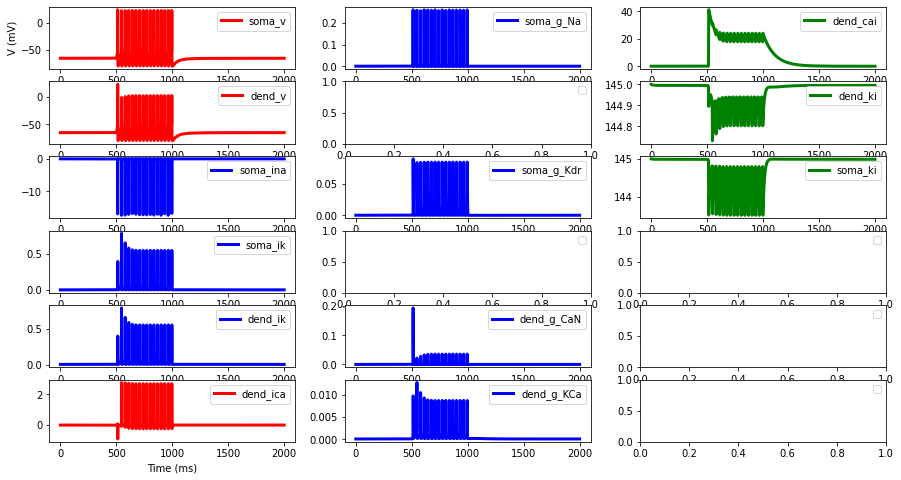

In [58]:
olm.plot_iclamp(param_dict=param_dict, stim_amp=0.2);

NEURON: Couldn't find: rn.hoc
 near line 0
 ^
INFO:interface.sopt_modeling:{'Ltotal': 21.01412010192871,
 'cm_ratio': 13.39218521118164,
 'dend_beta_Caconc': 0.009999999776482582,
 'dend_d_Caconc': 4.910271167755127,
 'dend_g_pas': 0.0,
 'dend_gmax_Ca': 0.3274633586406708,
 'dend_gmax_KCa': 0.7911216616630554,
 'e_pas': -62,
 'gc': 43.92416000366211,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'ic_constant_hold': -0.004158392548561096,
 'ic_constant_rest': -0.0005428391741588712,
 'pp': 0.7587454915046692,
 'soma_g_pas': 0.0006923977052792907,
 'soma_gmax_K': 0.2911522686481476,
 'soma_gmax_Na': 0.33878931403160095}


PRN_nrn[0].soma { nseg=1  L=15.9444  Ra=1698.71
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=40.1766}
	insert pas { g_pas=0.000692398 e_pas=-62}
	insert constant { ic_constant=-0.000542839}
	insert Na_PR { gmax_Na_PR=0.338789}
	insert K_PR { gmax_K_PR=0.291152}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PRN_nrn[0].dend { nseg=1  L=5.06975  Ra=16801.9
	PRN_nrn[0].soma connect PRN_nrn[0].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=0 e_pas=-62}
	insert Ca_PR { gmax_Ca_PR=0.327463}
	insert KCa_PR { gmax_KCa_PR=0.791122}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca_conc_PR=4.91027 beta_Ca_conc_PR=0.01}
	insert ca_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_con

INFO:interface.sopt_modeling:initial_v_error: 1.966341454817666e-05
INFO:interface.sopt_modeling:ic_constant0: -0.0001111549940725166
INFO:interface.sopt_modeling:ic_constant: -0.0005428391741588712
INFO:interface.sopt_modeling:mean initial vm constraint: 1
INFO:interface.sopt_modeling:soma ek = -89.7063966755447 ena = 60.43883162163455
INFO:interface.sopt_modeling:dend ek = -89.7063966755447 eca = 162.58785237096964
INFO:interface.sopt_modeling:soma nao = 145.0 ko = 5.0
INFO:interface.sopt_modeling:dend ki = 145.0 ko = 5.0
INFO:interface.sopt_modeling:dend cao = 2.0 cai = 1e-05
INFO:interface.sopt_modeling:spikes: (0, 41, -44.56853400282396, array([(25.48717889, 503.97, 70.05571289, 500.01, 504.73),
       (23.43848779, 516.69, 68.00702179, 504.74, 517.43),
       (23.2880691 , 529.02, 67.8566031 , 517.44, 529.78),
       (23.19067977, 541.27, 67.75921377, 529.79, 542.03),
       (23.23445243, 553.44, 67.80298643, 542.04, 554.21),
       (23.23648352, 565.62, 67.80501752, 554.22, 566.

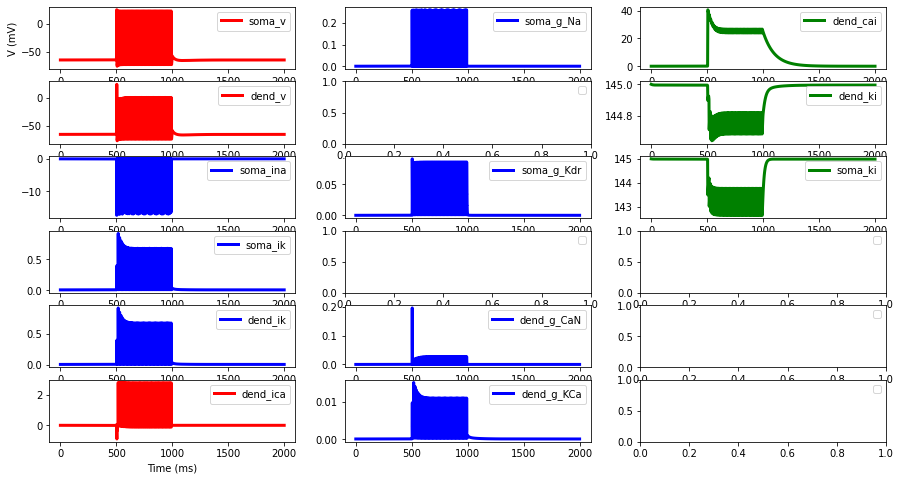

In [59]:
olm.plot_iclamp(param_dict=param_dict, stim_amp=0.8);

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

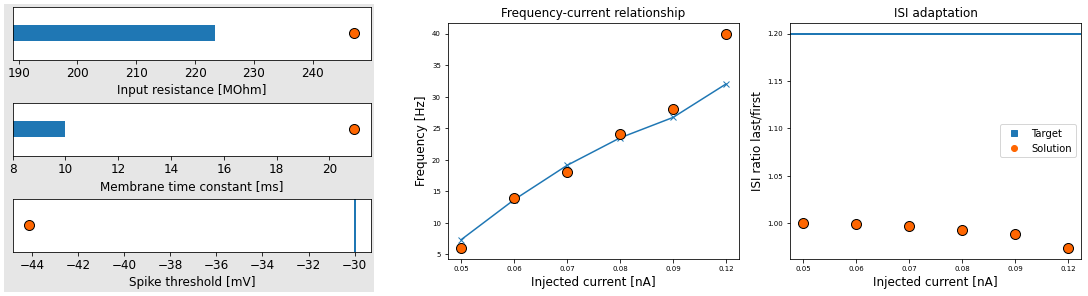

In [60]:
ngfc = interface.components[7]

ngfc.plot_features(best["NGFC"]["f"].iloc[10]);

In [62]:
solution_index = 10
param_dict = best["NGFC"]["x"].iloc[solution_index].to_dict()
feature_dict = best["NGFC"]["f"].iloc[solution_index].to_dict()
param_dict.update(
    {k: feature_dict[k] for k in ["ic_constant_hold", "ic_constant_rest"]}
)

NEURON: Couldn't find: rn.hoc
 near line 0
 ^
INFO:interface.sopt_modeling:{'Ltotal': 16.42649269104004,
 'cm_ratio': 26.981861114501953,
 'dend_aqs_KAHP': 2e-05,
 'dend_beta_Caconc': 0.075,
 'dend_bq_KAHP': 0.001,
 'dend_d_Caconc': 10.0,
 'dend_g_pas': 0.07237020134925842,
 'dend_gmax_Ca': 0.47226861119270325,
 'dend_gmax_KAHP': 0.20999298989772797,
 'dend_gmax_KCa': 0.6570940017700195,
 'e_pas': -72.0,
 'gc': 0.14876411855220795,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'ic_constant_hold': 0.011470569297671318,
 'ic_constant_rest': 0.011470569297671318,
 'pp': 0.2017993927001953,
 'soma_g_pas': 0.0027090786024928093,
 'soma_gmax_K': 0.21109849214553833,
 'soma_gmax_Na': 0.8999999761581421}


PR_nrn[0].soma { nseg=1  L=3.31486  Ra=3.08626e+06
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=80.9456}
	insert pas { g_pas=0.00270908 e_pas=-72}
	insert constant { ic_constant=0.0114706}
	insert Na_PR { gmax_Na_PR=0.9}
	insert K_PR { gmax_K_PR=0.211098}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PR_nrn[0].dend { nseg=1  L=13.1116  Ra=197264
	PR_nrn[0].soma connect PR_nrn[0].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=0.0723702 e_pas=-72}
	insert Ca_PR { gmax_Ca_PR=0.472269}
	insert KAHP_PR { gmax_KAHP_PR=0.209993 bq_KAHP_PR=0.001 aqs_KAHP_PR=2e-05 aqmax_KAHP_PR=0.01}
	insert KCa_PR { gmax_KCa_PR=0.657094}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca_conc_PR=

INFO:interface.sopt_modeling:initial_v_error: 0.001540523709635977
INFO:interface.sopt_modeling:ic_constant0: 0.007975352103248743
INFO:interface.sopt_modeling:ic_constant: 0.011470569297671318
INFO:interface.sopt_modeling:mean initial vm constraint: 0
INFO:interface.sopt_modeling:soma ek = -89.7063966755447 ena = 60.43883162163455
INFO:interface.sopt_modeling:dend ek = -89.7063966755447 eca = 162.58785237096964
INFO:interface.sopt_modeling:soma nao = 145.0 ko = 5.0
INFO:interface.sopt_modeling:dend ki = 145.0 ko = 5.0
INFO:interface.sopt_modeling:dend cao = 2.0 cai = 1e-05
INFO:interface.sopt_modeling:spikes: (0, 32, -44.176173736364746, array([(37.6216506 , 511.27, 81.79782433, 500.01, 512.61),
       (36.78099374, 527.77, 80.95716748, 512.62, 529.16),
       (36.45749154, 543.69, 80.63366528, 529.17, 545.11),
       (36.34066567, 559.42, 80.51683941, 545.12, 560.83),
       (36.30231783, 575.07, 80.47849156, 560.84, 576.48),
       (36.27381752, 590.72, 80.44999126, 576.49, 592.13),

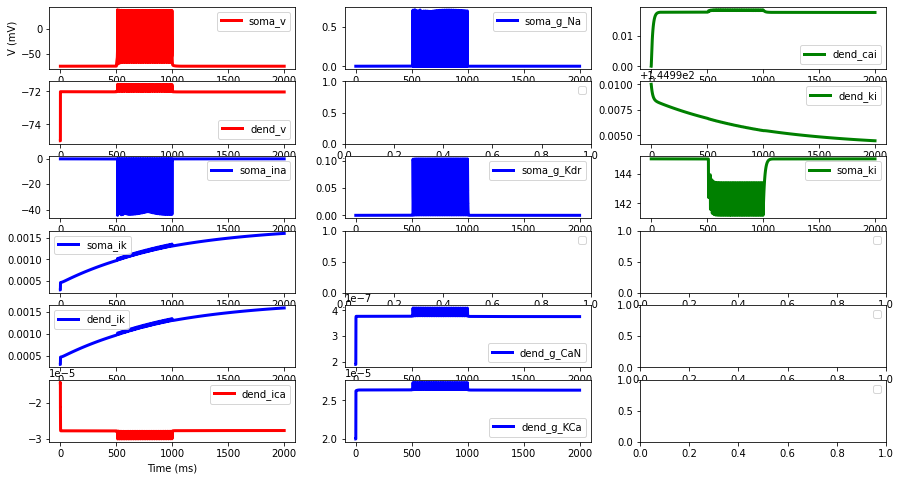

In [63]:
ngfc.plot_iclamp(param_dict=param_dict, stim_amp=0.2);

NEURON: Couldn't find: rn.hoc
 near line 0
 ^
INFO:interface.sopt_modeling:{'Ltotal': 16.42649269104004,
 'cm_ratio': 26.981861114501953,
 'dend_aqs_KAHP': 2e-05,
 'dend_beta_Caconc': 0.075,
 'dend_bq_KAHP': 0.001,
 'dend_d_Caconc': 10.0,
 'dend_g_pas': 0.07237020134925842,
 'dend_gmax_Ca': 0.47226861119270325,
 'dend_gmax_KAHP': 0.20999298989772797,
 'dend_gmax_KCa': 0.6570940017700195,
 'e_pas': -72.0,
 'gc': 0.14876411855220795,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'ic_constant_hold': 0.011470569297671318,
 'ic_constant_rest': 0.011470569297671318,
 'pp': 0.2017993927001953,
 'soma_g_pas': 0.0027090786024928093,
 'soma_gmax_K': 0.21109849214553833,
 'soma_gmax_Na': 0.8999999761581421}
INFO:interface.sopt_modeling:initial_v_error: 0.001540523709635977
INFO:interface.sopt_modeling:ic_constant0: 0.007975352103248743
INFO:interface.sopt_modeling:ic_constant: 0.011470569297671318
INFO:interface.sopt_modeling:mean initial vm constraint: 0
INFO:interface.sopt_modeling:soma ek = -89.70

PR_nrn[0].soma { nseg=1  L=3.31486  Ra=3.08626e+06
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=80.9456}
	insert pas { g_pas=0.00270908 e_pas=-72}
	insert constant { ic_constant=0.0114706}
	insert Na_PR { gmax_Na_PR=0.9}
	insert K_PR { gmax_K_PR=0.211098}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PR_nrn[0].dend { nseg=1  L=13.1116  Ra=197264
	PR_nrn[0].soma connect PR_nrn[0].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=0.0723702 e_pas=-72}
	insert Ca_PR { gmax_Ca_PR=0.472269}
	insert KAHP_PR { gmax_KAHP_PR=0.209993 bq_KAHP_PR=0.001 aqs_KAHP_PR=2e-05 aqmax_KAHP_PR=0.01}
	insert KCa_PR { gmax_KCa_PR=0.657094}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca_conc_PR=

INFO:interface.sopt_modeling:spikes: (0, 4, -44.9470186185724, array([(38.96355639, 503.19, 83.91057501, 500.01, 504.66),
       (30.612189  , 510.49, 75.55920761, 504.67, 512.16),
       (24.41004927, 517.09, 69.35706789, 512.17, 518.96),
       (18.11312861, 523.07, 63.06014723, 518.97, 525.21)],
      dtype=[('Vpeak', '<f8'), ('Tpeak', '<f8'), ('amplitude', '<f8'), ('T0', '<f8'), ('T1', '<f8')]))
INFO:interface.sopt_modeling:dend ki min/max: 144.99444541559308 / 145.0


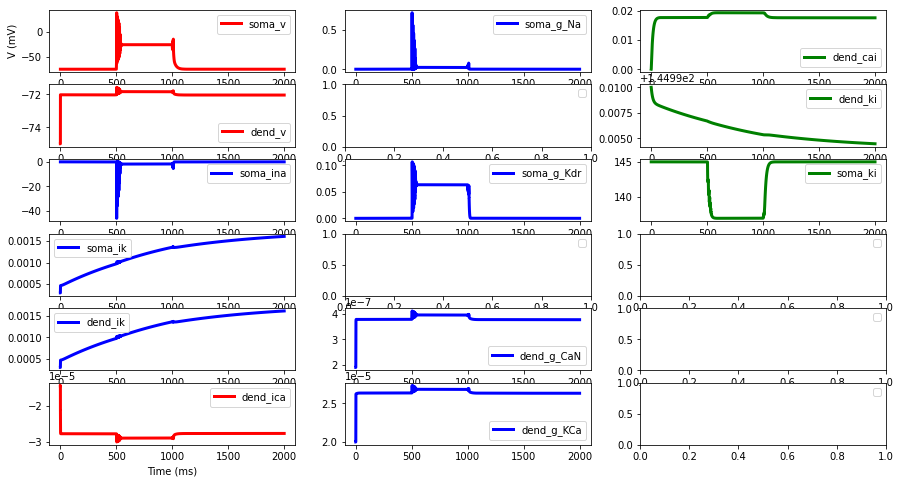

In [64]:
ngfc.plot_iclamp(param_dict=param_dict, stim_amp=0.8);

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

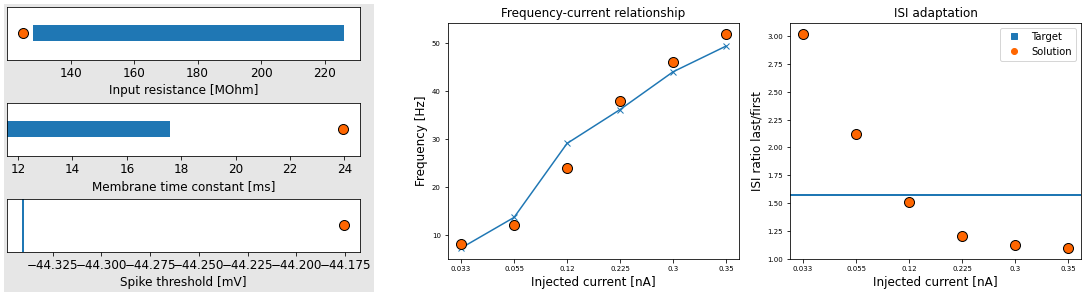

In [66]:
isc = interface.components[8]

isc.plot_features(best["IS"]["f"].iloc[93]);

In [68]:
solution_index = 93
param_dict = best["IS"]["x"].iloc[solution_index].to_dict()
feature_dict = best["IS"]["f"].iloc[solution_index].to_dict()
param_dict.update(
    {k: feature_dict[k] for k in ["ic_constant_hold", "ic_constant_rest"]}
)

NEURON: Couldn't find: rn.hoc
 near line 0
 ^
INFO:interface.sopt_modeling:{'Ltotal': 12.19237232208252,
 'cm_ratio': 26.451040267944336,
 'dend_aqs_KAHP': 2e-05,
 'dend_beta_Caconc': 0.075,
 'dend_bq_KAHP': 0.001,
 'dend_d_Caconc': 13.0,
 'dend_g_pas': 0.008655774407088757,
 'dend_gmax_Ca': 0.26603299379348755,
 'dend_gmax_KAHP': 0.041475556790828705,
 'dend_gmax_KCa': 0.8999999761581421,
 'e_pas': -62,
 'gc': 22.959630966186523,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'ic_constant_hold': -0.01879761926829815,
 'ic_constant_rest': -0.01879761926829815,
 'pp': 0.7672945857048035,
 'soma_g_pas': 0.0012158723548054695,
 'soma_gmax_K': 0.8660700917243958,
 'soma_gmax_Na': 0.7784022688865662}
INFO:interface.sopt_modeling:initial_v_error: -4.539732298525223e-05
INFO:interface.sopt_modeling:ic_constant0: -0.014239379776141349
INFO:interface.sopt_modeling:ic_constant: -0.01879761926829815
INFO:interface.sopt_modeling:mean initial vm constraint: 1
INFO:interface.sopt_modeling:soma ek = -89.7

PR_nrn[0].soma { nseg=1  L=9.35514  Ra=9546.33
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=79.3531}
	insert pas { g_pas=0.00121587 e_pas=-62}
	insert constant { ic_constant=-0.0187976}
	insert Na_PR { gmax_Na_PR=0.778402}
	insert K_PR { gmax_K_PR=0.86607}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PR_nrn[0].dend { nseg=1  L=2.83723  Ra=103788
	PR_nrn[0].soma connect PR_nrn[0].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=0.00865577 e_pas=-62}
	insert Ca_PR { gmax_Ca_PR=0.266033}
	insert KAHP_PR { gmax_KAHP_PR=0.0414756 bq_KAHP_PR=0.001 aqs_KAHP_PR=2e-05 aqmax_KAHP_PR=0.01}
	insert KCa_PR { gmax_KCa_PR=0.9}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca_conc_PR=13

INFO:interface.sopt_modeling:spikes: (0, 18, -44.149933812181004, array([(24.81805353, 507.04, 68.96798734, 500.01, 507.68),
       (24.51933558, 532.89, 68.66926939, 507.69, 533.53),
       (24.52478668, 558.57, 68.67472049, 533.54, 559.23),
       (24.50302772, 584.67, 68.65296153, 559.24, 585.31),
       (24.49066313, 611.19, 68.64059695, 585.32, 611.83),
       (24.50003398, 638.17, 68.64996779, 611.84, 638.83),
       (24.45203843, 665.62, 68.60197225, 638.84, 666.26),
       (24.41324331, 693.52, 68.56317712, 666.27, 694.16),
       (24.47229517, 721.87, 68.62222899, 694.17, 722.51),
       (24.46978381, 750.67, 68.61971762, 722.52, 751.33),
       (24.48722694, 779.94, 68.63716075, 751.34, 780.58),
       (24.44159337, 809.67, 68.59152718, 780.59, 810.31),
       (24.41214882, 839.82, 68.56208263, 810.32, 840.48),
       (24.48096748, 870.44, 68.63090129, 840.49, 871.08),
       (24.46695351, 901.49, 68.61688732, 871.09, 902.16),
       (24.45012746, 932.99, 68.60006127, 902.17,

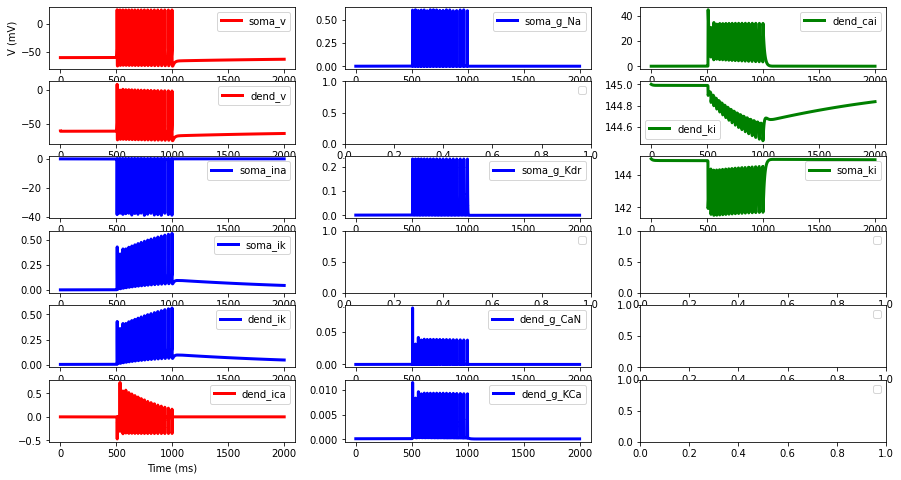

In [69]:
isc.plot_iclamp(param_dict=param_dict, stim_amp=0.2);

NEURON: Couldn't find: rn.hoc
 near line 0
 ^
INFO:interface.sopt_modeling:{'Ltotal': 12.19237232208252,
 'cm_ratio': 26.451040267944336,
 'dend_aqs_KAHP': 2e-05,
 'dend_beta_Caconc': 0.075,
 'dend_bq_KAHP': 0.001,
 'dend_d_Caconc': 13.0,
 'dend_g_pas': 0.008655774407088757,
 'dend_gmax_Ca': 0.26603299379348755,
 'dend_gmax_KAHP': 0.041475556790828705,
 'dend_gmax_KCa': 0.8999999761581421,
 'e_pas': -62,
 'gc': 22.959630966186523,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'ic_constant_hold': -0.01879761926829815,
 'ic_constant_rest': -0.01879761926829815,
 'pp': 0.7672945857048035,
 'soma_g_pas': 0.0012158723548054695,
 'soma_gmax_K': 0.8660700917243958,
 'soma_gmax_Na': 0.7784022688865662}


PR_nrn[0].soma { nseg=1  L=9.35514  Ra=9546.33
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=79.3531}
	insert pas { g_pas=0.00121587 e_pas=-62}
	insert constant { ic_constant=-0.0187976}
	insert Na_PR { gmax_Na_PR=0.778402}
	insert K_PR { gmax_K_PR=0.86607}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PR_nrn[0].dend { nseg=1  L=2.83723  Ra=103788
	PR_nrn[0].soma connect PR_nrn[0].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=0.00865577 e_pas=-62}
	insert Ca_PR { gmax_Ca_PR=0.266033}
	insert KAHP_PR { gmax_KAHP_PR=0.0414756 bq_KAHP_PR=0.001 aqs_KAHP_PR=2e-05 aqmax_KAHP_PR=0.01}
	insert KCa_PR { gmax_KCa_PR=0.9}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca_conc_PR=13

INFO:interface.sopt_modeling:initial_v_error: -4.539732298525223e-05
INFO:interface.sopt_modeling:ic_constant0: -0.014239379776141349
INFO:interface.sopt_modeling:ic_constant: -0.01879761926829815
INFO:interface.sopt_modeling:mean initial vm constraint: 1
INFO:interface.sopt_modeling:soma ek = -89.7063966755447 ena = 60.43883162163455
INFO:interface.sopt_modeling:dend ek = -89.7063966755447 eca = 162.58785237096964
INFO:interface.sopt_modeling:soma nao = 145.0 ko = 5.0
INFO:interface.sopt_modeling:dend ki = 145.0 ko = 5.0
INFO:interface.sopt_modeling:dend cao = 2.0 cai = 1e-05
INFO:interface.sopt_modeling:spikes: (0, 41, -44.49024988965639, array([(25.39185226, 502.82, 69.88210215, 500.01, 503.46),
       (24.48150883, 515.22, 68.97175872, 503.47, 515.91),
       (24.06234772, 527.27, 68.55259761, 515.92, 527.98),
       (23.76358669, 539.22, 68.25383658, 527.99, 539.93),
       (23.65417039, 551.09, 68.14442028, 539.94, 551.83),
       (23.68671923, 562.99, 68.17696912, 551.84, 563.71

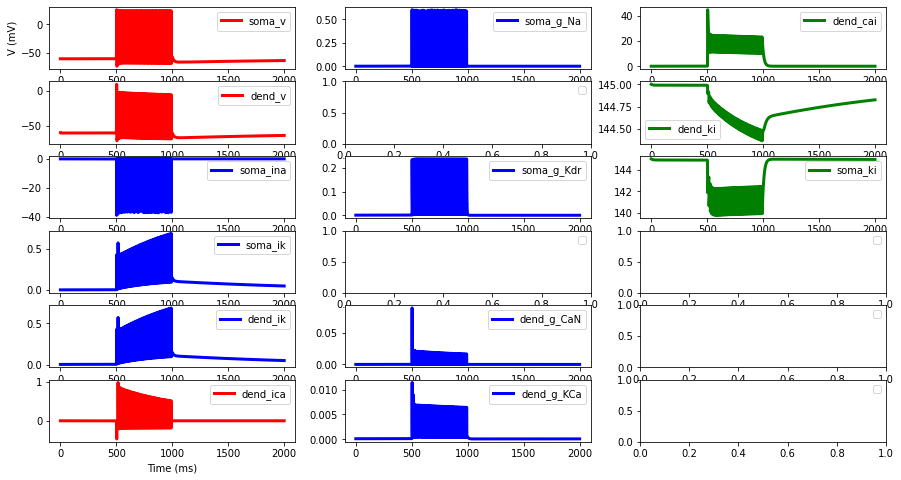

In [70]:
isc.plot_iclamp(param_dict=param_dict, stim_amp=0.8);